In [1]:
library(tidyverse) # metapackage of all tidyverse packages

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
fig <- function(width, height){
     options(repr.plot.width = width, repr.plot.height = height)
}
fig(10, 10)
theme_set(theme(text=element_text(size=24)))

In [63]:
game = "Scopa"
c = paste("../CardStock/output/", game, "/2/RndandAI/PIPMCNEW/choicestats.txt", sep="")

In [64]:
choices = read_csv(c)

Rows: 1800 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): game, type, ai
dbl (6): numPlayers, iteration, move, player, choices, choice

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [65]:
choices

game,numPlayers,type,ai,iteration,move,player,choices,choice
<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Agram,3,RndandAI,BOTH,0,0,0,6,2
Agram,3,RndandAI,BOTH,0,1,1,3,1
Agram,3,RndandAI,BOTH,0,2,2,1,0
Agram,3,RndandAI,BOTH,0,3,2,5,1
Agram,3,RndandAI,BOTH,0,4,0,1,0
Agram,3,RndandAI,BOTH,0,5,1,1,0
Agram,3,RndandAI,BOTH,0,6,1,4,0
Agram,3,RndandAI,BOTH,0,7,2,4,2
Agram,3,RndandAI,BOTH,0,8,0,4,2


`geom_smooth()` using formula = 'y ~ x'


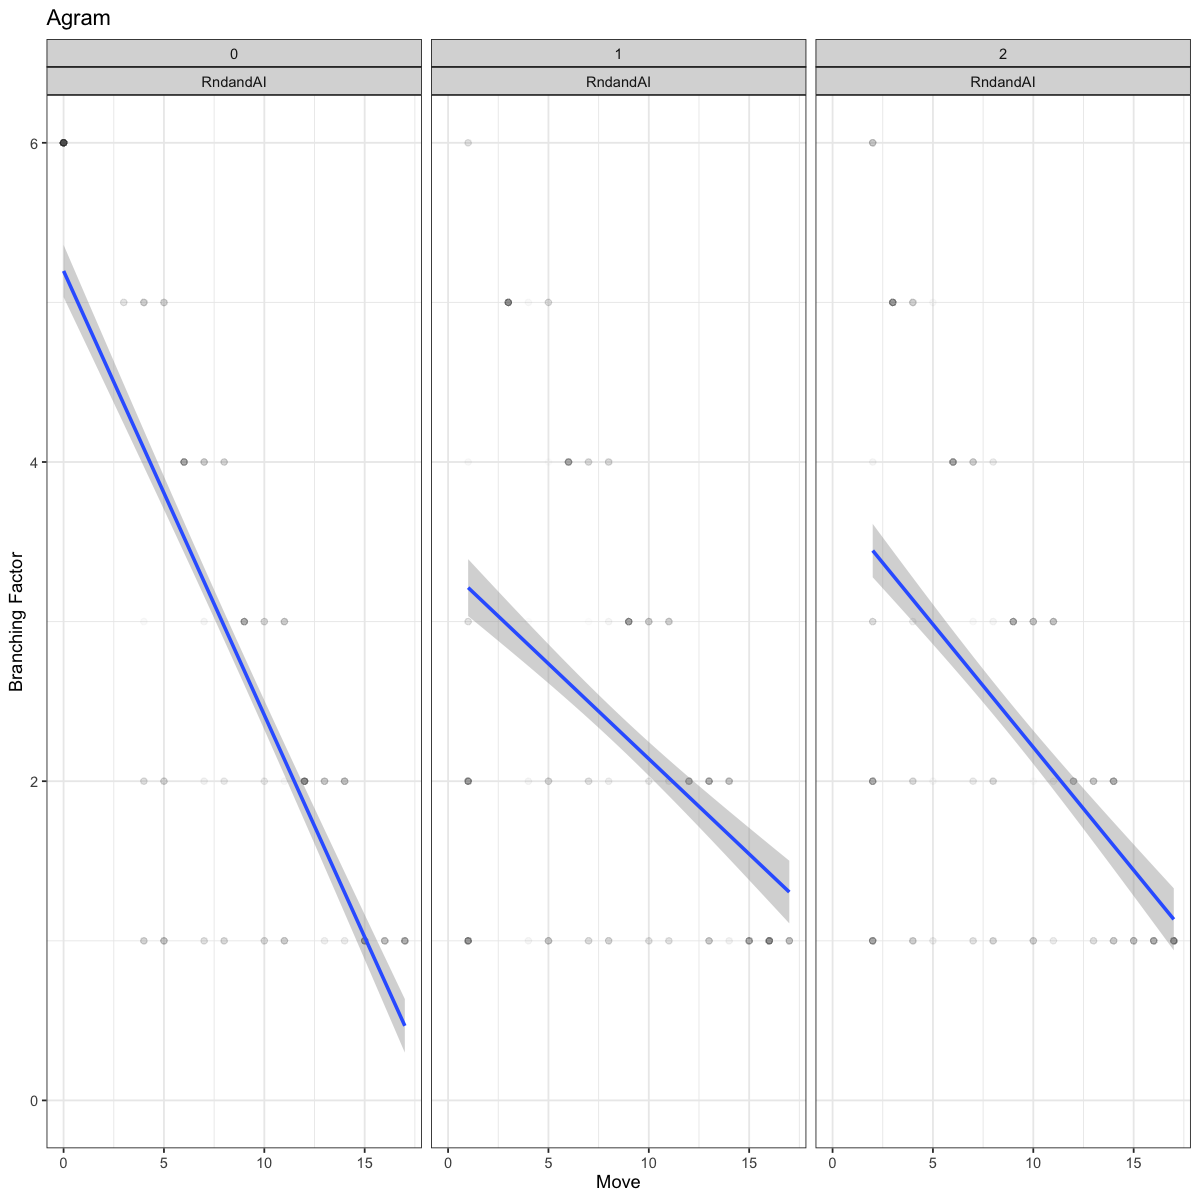

In [66]:
choices %>% ggplot(aes(x=move, y=choices)) +
geom_point(alpha= 0.01) +
geom_smooth(method="lm") +
facet_wrap(vars(player, type), ncol = 3) +
theme_bw() +
aes(ymin=0) +
labs(x='Move', y='Branching Factor', title=game)

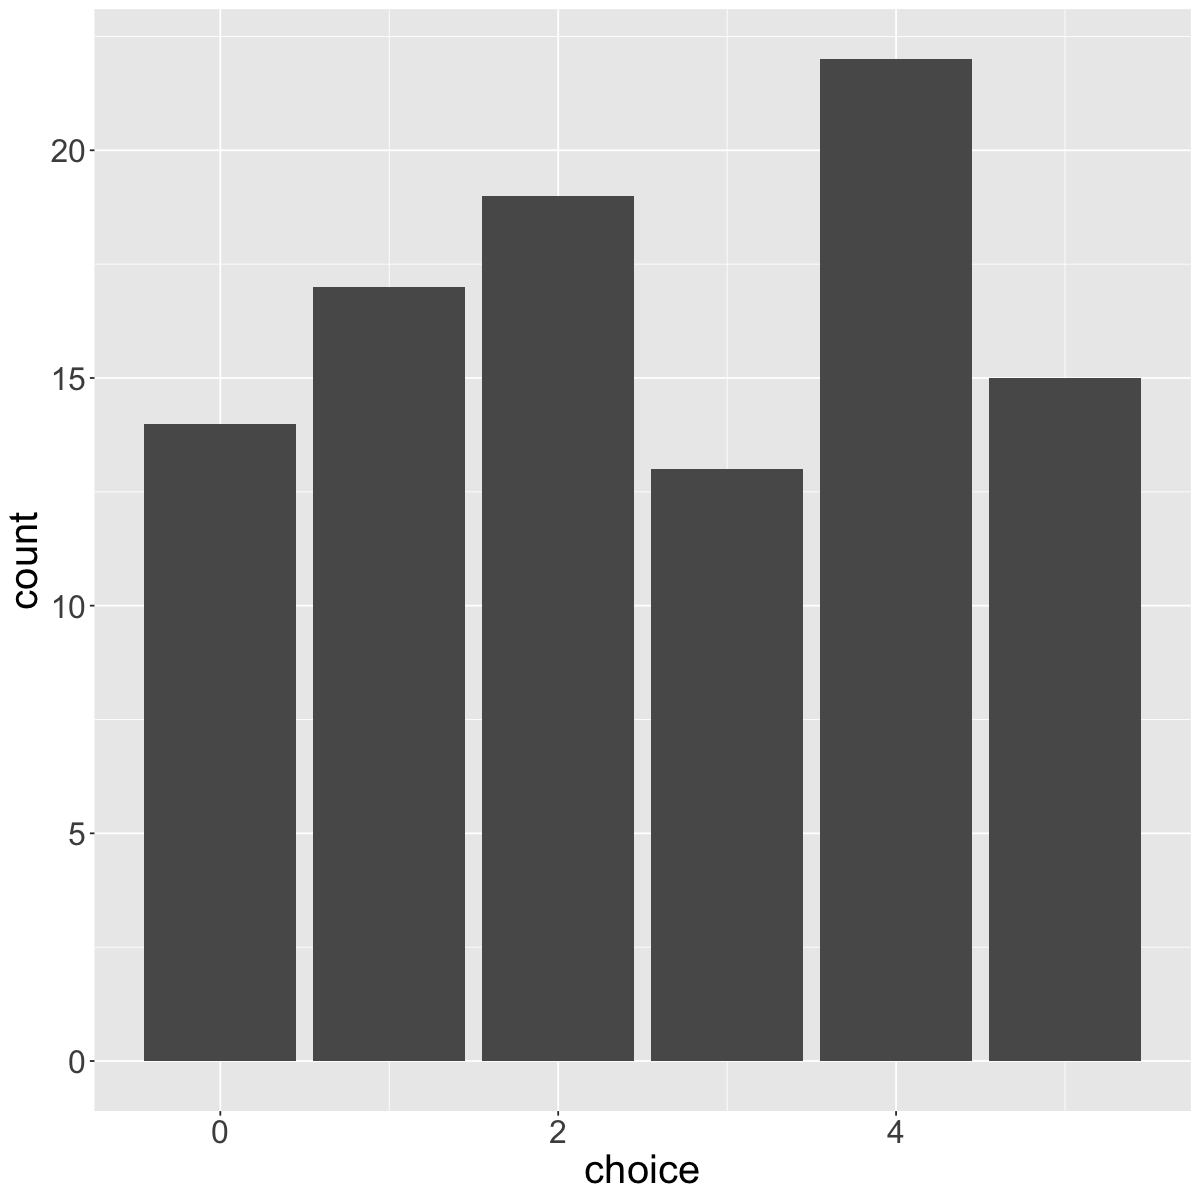

In [54]:
choices %>% filter(move==0) %>% filter(player==0) %>% ggplot(aes(x=choice)) +
geom_bar()

In [121]:
mcts = read_csv(paste("../CardStock/output/", game, "/3/AllRnd-RANDOM-resultsstats.txt", sep=""))
pipmc = read_csv(paste("../CardStock/output/", game, "/3/RndandAI-PIPMCNEW-resultsstats.txt", sep=""))
all = rbind(pipmc, mcts)

Rows: 300 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): game, type, ai
dbl (5): numPlayers, iteration, player, score, rank

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 300 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): game, type, ai
dbl (5): numPlayers, iteration, player, score, rank

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [122]:
summary(all)

     game             numPlayers     type                ai           
 Length:600         Min.   :3    Length:600         Length:600        
 Class :character   1st Qu.:3    Class :character   Class :character  
 Mode  :character   Median :3    Mode  :character   Mode  :character  
                    Mean   :3                                         
                    3rd Qu.:3                                         
                    Max.   :3                                         
   iteration         player      score             rank       
 Min.   : 0.00   Min.   :0   Min.   :0.0000   Min.   :0.0000  
 1st Qu.:24.75   1st Qu.:0   1st Qu.:0.0000   1st Qu.:0.0000  
 Median :49.50   Median :1   Median :0.0000   Median :1.0000  
 Mean   :49.50   Mean   :1   Mean   :0.3333   Mean   :0.6667  
 3rd Qu.:74.25   3rd Qu.:2   3rd Qu.:1.0000   3rd Qu.:1.0000  
 Max.   :99.00   Max.   :2   Max.   :1.0000   Max.   :1.0000  

In [123]:
all %>% filter(player==0)

game,numPlayers,type,ai,iteration,player,score,rank
<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Agram,3,RndandAI,PIPMCNEW,0,0,1,0
Agram,3,RndandAI,PIPMCNEW,1,0,1,0
Agram,3,RndandAI,PIPMCNEW,2,0,1,0
Agram,3,RndandAI,PIPMCNEW,3,0,0,1
Agram,3,RndandAI,PIPMCNEW,4,0,0,1
Agram,3,RndandAI,PIPMCNEW,5,0,0,1
Agram,3,RndandAI,PIPMCNEW,6,0,1,0
Agram,3,RndandAI,PIPMCNEW,7,0,1,0
Agram,3,RndandAI,PIPMCNEW,8,0,1,0


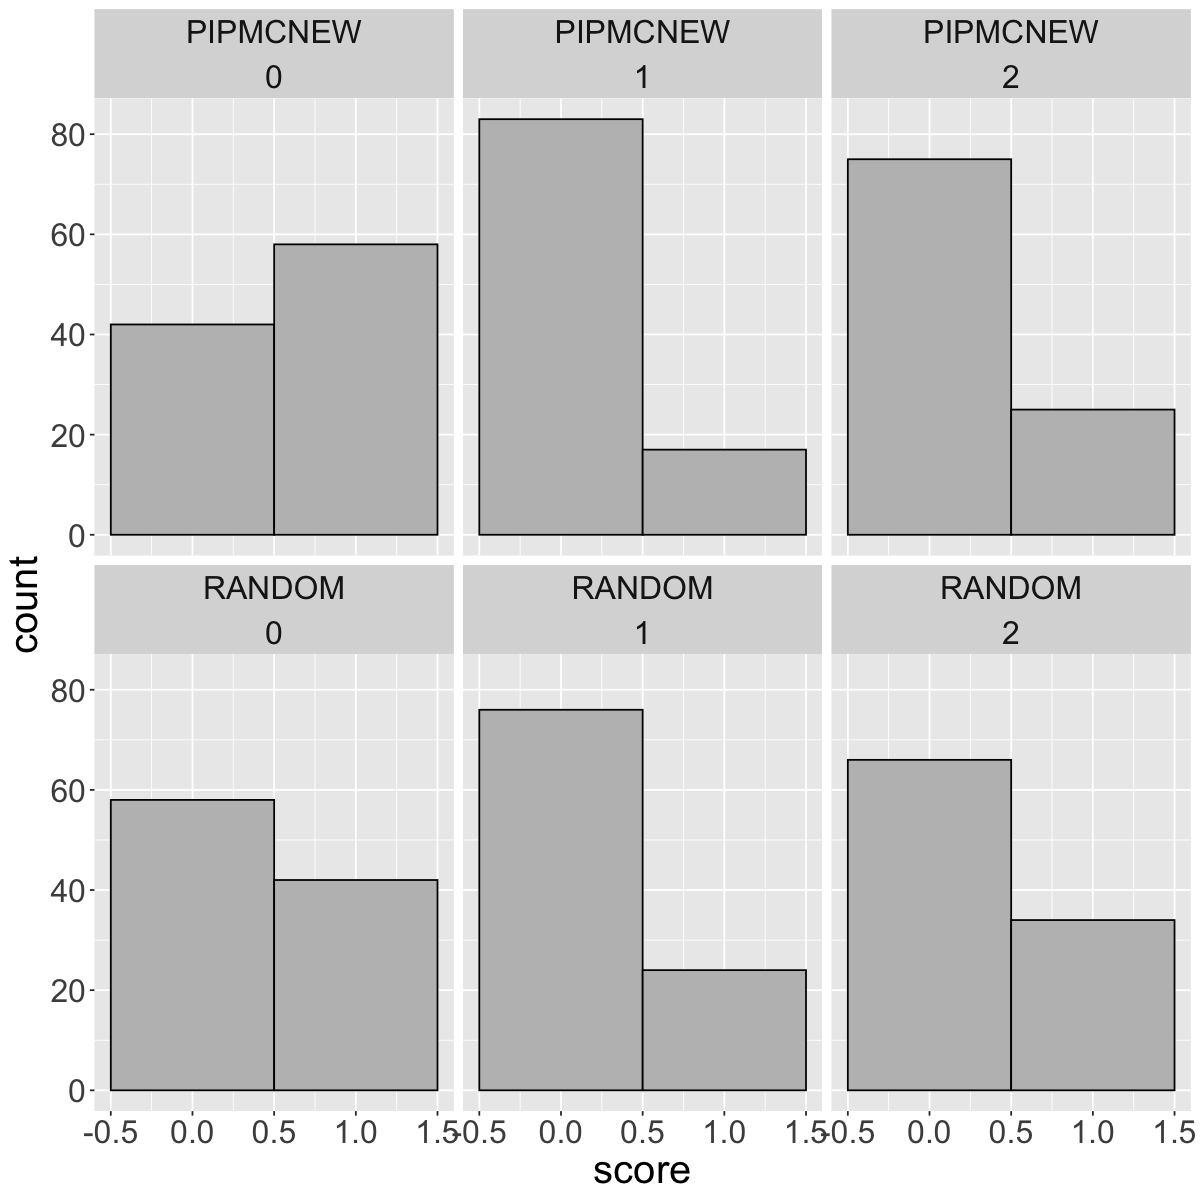

In [124]:
all %>% ggplot(aes(x=score)) + 
geom_histogram(bins = 2, color="black", fill="grey") + 
facet_wrap(vars(ai, player))

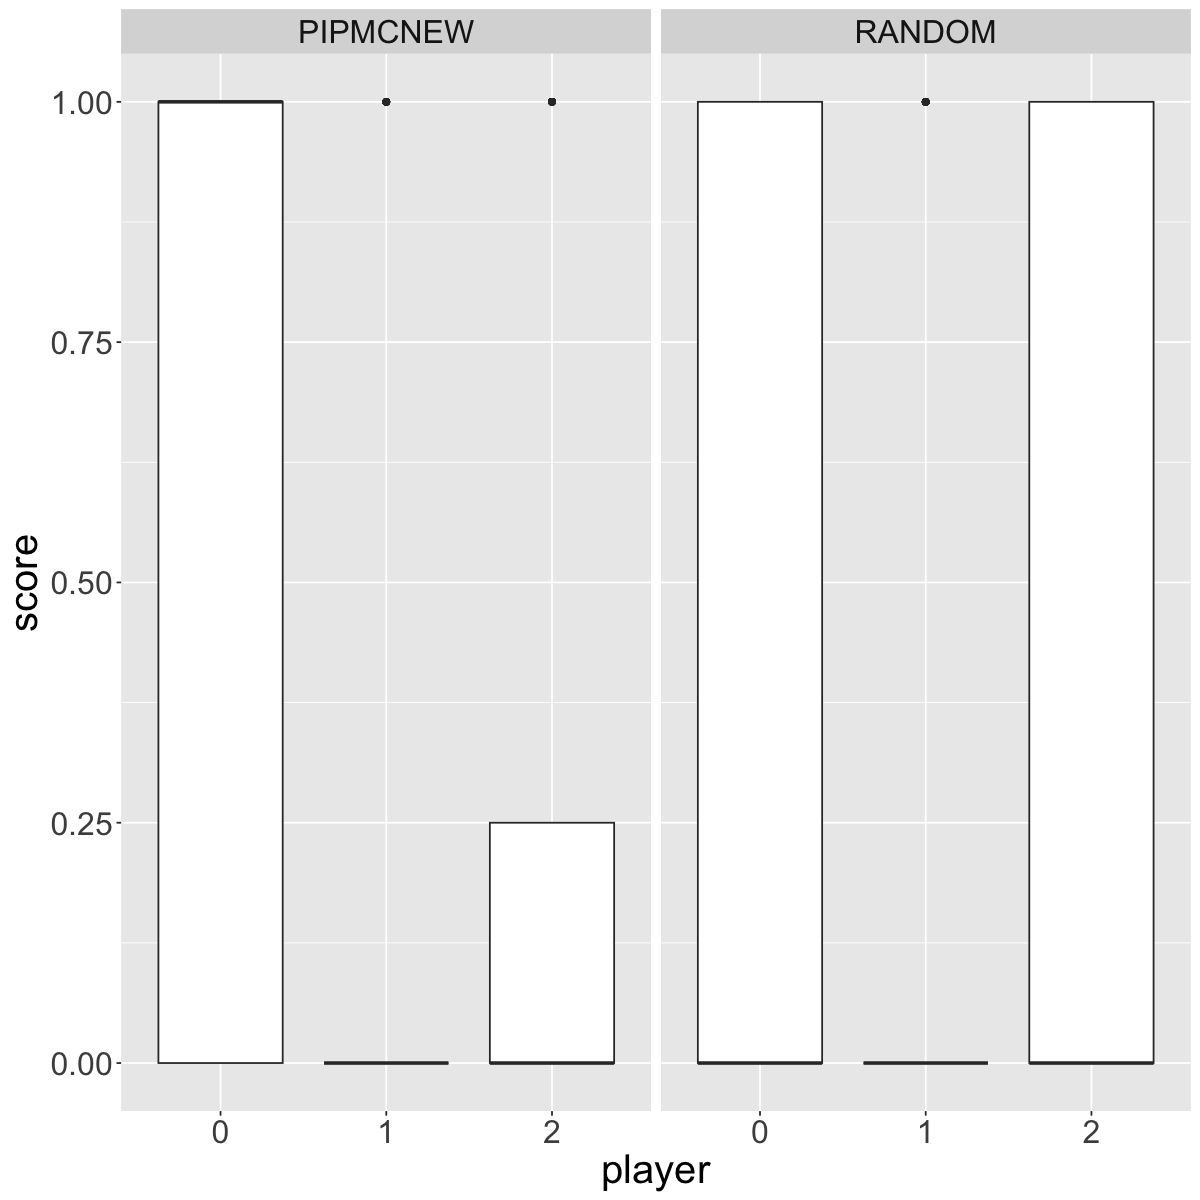

In [125]:
all <- all %>%
  mutate(player = replace(player, player ==  0, "0"))
all <- all %>%
  mutate(player = replace(player, player ==  1, "1"))

all %>% ggplot(aes(x=player, y=score)) + 
geom_boxplot() +
facet_wrap(vars(ai))

In [126]:
all %>% filter(player==0) %>% t.test(score ~ ai, data = ., alternative="two.sided")



	Welch Two Sample t-test

data:  score by ai
t = 2.2808, df = 198, p-value = 0.02363
alternative hypothesis: true difference in means between group PIPMCNEW and group RANDOM is not equal to 0
95 percent confidence interval:
 0.02166031 0.29833969
sample estimates:
mean in group PIPMCNEW   mean in group RANDOM 
                  0.58                   0.42 


In [127]:
all %>% filter(player==0) %>% group_by(ai) %>%
  summarize(mean = mean(score), n = n())

ai,mean,n
<chr>,<dbl>,<int>
PIPMCNEW,0.58,100
RANDOM,0.42,100


In [128]:
all %>% filter(player==0) %>% group_by(ai) %>%
  summarize(sd = sd(score), n = n())

ai,sd,n
<chr>,<dbl>,<int>
PIPMCNEW,0.496045,100
RANDOM,0.496045,100


In [129]:
agram.aov <- all %>% filter(player==0) %>% aov(score ~ ai, data = .)


In [130]:
anova(agram.aov)

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
ai,1,1.28,1.2800000,5.20197,0.02362591
Residuals,198,48.72,0.2460606,NA,NA
